# Hochschule für Musik, Theater und Medien Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Hochschule für Musik, Theater und Medien Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00x67m532' -- 'Hochschule für Musik, Theater und Medien Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W4212957902
1,not assigned,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W4221101099
2,not assigned,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W4221101099
3,not assigned,"Hochschule für Musik, Theater und Medien Hannover",Leibniz Lab for Relational Communication Resea...,https://openalex.org/W4303470830
4,not assigned,"Hochschule für Musik, Theater und Medien Hannover",Institut für Journalistik und Kommunikationsfo...,https://openalex.org/W4313410724


In [6]:
MAPPING_DICT = {
    #'Europäisches Zentrum für Jüdische Musik (EZJM)': [],
    #'Fachbereich Musiktheorie': [],
    #'Forschungszentrum Musik und Gender': [],
    #'Institut für Alte Musik': [],
    'Institut für Journalistik und Kommunikationsforschung': ['journalism', 'journalistik', 'kommunikationsforschung',
                                                              'communication research'
                                                             ],
    #'Institut für Kammermusik': [],
    'Institut für Musikphysiologie und Musikermedizin': ['physiology', 'musikphysiologie'],
    'Institut für Musikpädagogische Forschung': ['music education research'],
    #'Institut für Neue Musik': [],
    'Institut zur Früh-Förderung musikalisch Hochbegabter': ['music lab'],
    'Musikwissenschaftliches Institut': ['musicology', 'musikwissenschaftliches'],
    #'Popinstitut Hannover': [],
    #'Studienzentrum Weltmusik': []
}

In [7]:
with open('./mapping_tables_fak/hmtmh.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [8]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [9]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [10]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W4212957902
1,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W4221101099
2,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W4221101099
3,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Leibniz Lab for Relational Communication Resea...,https://openalex.org/W4303470830
4,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Institut für Journalistik und Kommunikationsfo...,https://openalex.org/W4313410724
...,...,...,...,...
332,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W3216035224
333,None,"Hochschule für Musik, Theater und Medien Hannover","Hanover University of Music, Drama and Media, ...",https://openalex.org/W3039069332
334,Institut für Journalistik und Kommunikationsfo...,"Hochschule für Musik, Theater und Medien Hannover",Department of Journalism and Communication Res...,https://openalex.org/W3155745294
335,None,"Hochschule für Musik, Theater und Medien Hannover","Hochschule für Musik, Theater und Medien Hannover",https://openalex.org/W4394854711


In [11]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Hanover University of Music, Drama and Media, Hanover, Germany',
       'Hanover University of Music, Drama and Media',
       'Hochschule für Musik, Theater und Medien Hannover',
       'Hanover University of Music, Drama, and Media',
       'University of Veterinary Medicine Hannover, ITZ, Division of Ecology and Evolution, Bünteweg 17d, 30559 Hannover, Germany 2American Museum of Natural History, Division of Invertebrate Zoology, Central Park West, W 81st Street, New York, NY 10024, USA',
       "University of Veterinary Medicine Hannover, ITZ, Division of Ecology and Evolution, Bünteweg 17d, 30559 Hannover, Germany 2American Museum of Natural History, Division of Invertebrate Zoology, Central Park West, W 81st Street, New York, NY 10024, USA. ITZ—Forschungsstätte 'Alter Bahnhof Schapen' Braunschweig, University of Veterinary Medicine Hannover, Hannover/Braunschweig, Germany",
       'Hanover University of Music, Drama, and Media, Germany',
       'Hanover University of Musi

In [12]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Institut für Journalistik und Kommunikationsfo...,106
1,Institut für Musikphysiologie und Musikermedizin,110
2,Institut für Musikpädagogische Forschung,4
3,Institut zur Früh-Förderung musikalisch Hochbe...,12
4,Musikwissenschaftliches Institut,4
5,NaN,101


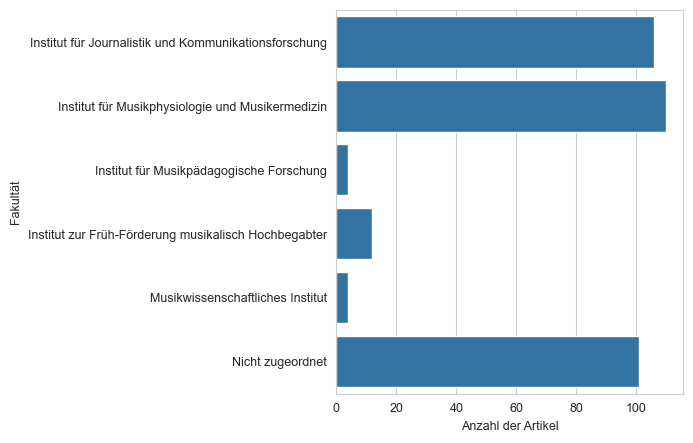

In [13]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [14]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7002967359050445